In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = sns.load_dataset('tips')

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
X = df[['total_bill', 'tip', 'size']]

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)
labels

array([ 0, -1,  1,  0,  2, -1,  0,  2,  0,  0,  0, -1,  0,  2,  0,  0, -1,
        1,  1,  1,  0,  0,  0, -1,  0,  2,  0,  0,  0,  0,  0,  2,  0,  2,
        0,  1,  1,  1,  1, -1,  1,  0,  0,  0, -1,  0, -1, -1, -1,  0,  0,
        0, -1,  0,  2,  0, -1,  0,  0, -1,  0,  0,  0,  2,  1,  1,  0, -1,
        0,  0,  0,  1,  0, -1,  0,  0,  0,  2,  0,  0,  0,  0, -1, -1,  0,
       -1,  0,  0, -1,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  1,  0, -1,  0,  0,
        2,  0,  0,  0,  0,  0, -1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0, -1, -1, -1,  0,  0, -1,  0,  0,  0,  0,  0,  1,
       -1,  2, -1, -1,  2,  0,  2,  2,  0,  1,  0,  0,  1,  0, -1,  0,  0,
       -1,  0, -1,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1,  1,
       -1,  1,  1,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  1,  0,  0,  0,
        2,  1,  1, -1,  0,  0, -1, -1, -1,  0, -1,  0, -1,  0,  0, -1,  0,
        0, -1,  1,  0,  0

In [9]:
df['Cluster'] = labels

print(df.head())

   total_bill   tip     sex smoker  day    time  size  Cluster
0       16.99  1.01  Female     No  Sun  Dinner     2        0
1       10.34  1.66    Male     No  Sun  Dinner     3       -1
2       21.01  3.50    Male     No  Sun  Dinner     3        1
3       23.68  3.31    Male     No  Sun  Dinner     2        0
4       24.59  3.61  Female     No  Sun  Dinner     4        2


In [10]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Number of Clusters:", n_clusters)

Number of Clusters: 3


## Evaluation Metrics
## Silhouette Score

In [11]:
from sklearn.metrics import silhouette_score

if len(set(labels)) > 1:
    score = silhouette_score(X_scaled, labels)
    print("Silhouette Score:", score)

Silhouette Score: 0.2203395412217939


## Davies-Bouldin Index

In [12]:
from sklearn.metrics import davies_bouldin_score

if len(set(labels)) > 1:
    dbi = davies_bouldin_score(X_scaled, labels)
    print("DBI:", dbi)

DBI: 1.625671318815124


## Calinski-Harabasz Score

In [13]:
from sklearn.metrics import calinski_harabasz_score

if len(set(labels)) > 1:
    ch = calinski_harabasz_score(X_scaled, labels)
    print("CH Score:", ch)

CH Score: 62.403353711869485


## Visualize Clusters

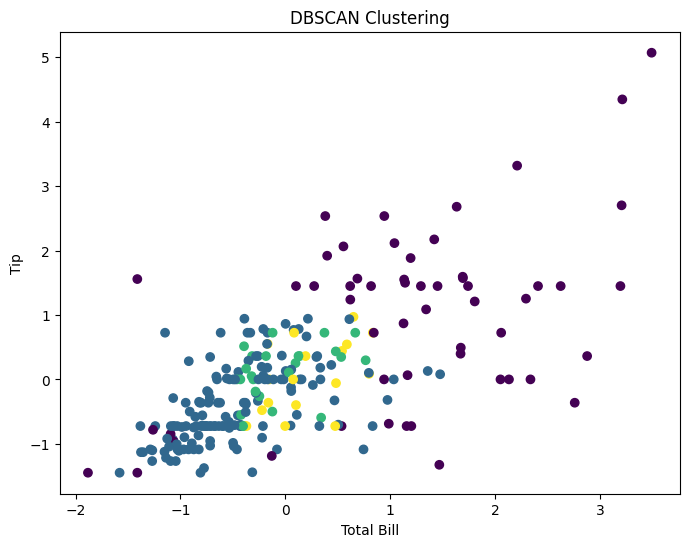

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=labels
)

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("DBSCAN Clustering")
plt.show()

## Hyperparameter Tuning DBSCAN

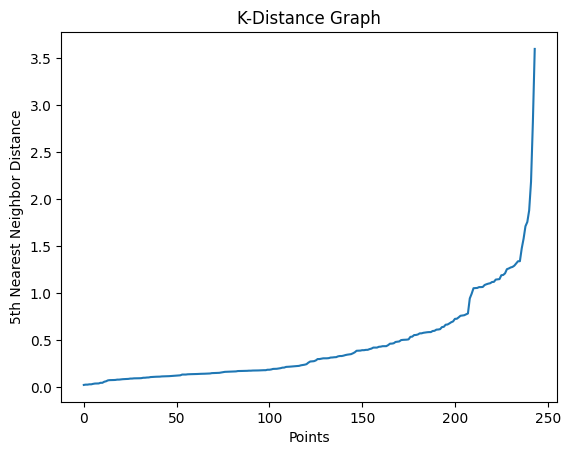

In [15]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.xlabel("Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Graph")
plt.show()